In [ ]:
import os
os.environ.setdefault("LEVIR_DATA_FOLDER", "/data/gaetane/LEVIR-CD")  # adapte si besoin (avant l'import du dataloader)

import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, f1_score
from test.ipynb import visualize 
from levir_dataset import LEVIRCD_Dataset
from encoder import DinoV2Encoder
from encoder import ChangeDetectionModel
from encoder import FeatureTransformer
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", device, torch.cuda.get_device_name(0) if device == "cuda" else "")



device : cuda NVIDIA GeForce RTX 3090


In [2]:
EXPECTED = {"train": 445, "val": 64, "test": 128}
for split in ["train", "val", "test"]:
    counts = {sub: len([f for f in os.listdir(os.path.join(DATA_FOLDER, split, sub)) if f.endswith(".png")])
              for sub in ["A", "B", "label"]}
    print(split, counts)
    assert counts["A"] == counts["B"] == counts["label"], f"{split}: A/B/label counts differ"
    if counts["A"] != EXPECTED[split]:
        print(f"  WARNING: expected {EXPECTED[split]} pairs in {split}")

train {'A': 445, 'B': 445, 'label': 445}
val {'A': 64, 'B': 64, 'label': 64}
test {'A': 128, 'B': 128, 'label': 128}


In [3]:
split = "train"
names = sorted(os.listdir(os.path.join(DATA_FOLDER, split, "A")))[:20]
label_values = set()
for n in names:
    a = Image.open(os.path.join(DATA_FOLDER, split, "A", n))
    b = Image.open(os.path.join(DATA_FOLDER, split, "B", n))
    l = Image.open(os.path.join(DATA_FOLDER, split, "label", n))
    assert a.size == b.size == l.size, n
    label_values |= set(np.unique(np.array(l.convert("L"))).tolist())
print("A:", a.size, a.mode, "| B:", b.size, b.mode, "| label:", l.size, l.mode)
print("Label values in 20 files:", sorted(label_values))
assert label_values <= {0, 255}, "Unexpected label values -> check the > 127 threshold in the dataset"

A: (1024, 1024) RGB | B: (1024, 1024) RGB | label: (1024, 1024) L
Label values in 20 files: [0, 255]


In [4]:
CS = 256
ds_train = LEVIRCD_Dataset(cropsize=CS, type="train")
ds_val   = LEVIRCD_Dataset(cropsize=CS, type="val")
ds_test  = LEVIRCD_Dataset(cropsize=CS, type="test", get_name=True)
for ds in [ds_train, ds_val, ds_test]:
    print(f"{ds.type:5s}: {len(ds.names)} images -> {len(ds)} samples "
          f"({ds.tiles_per_image} tile(s)/image), augment={ds.augment}")
assert len(ds_val) == len(ds_val.names) * (1024 // CS) ** 2

train: 445 images -> 445 samples (1 tile(s)/image), augment=True
val  : 64 images -> 1024 samples (16 tile(s)/image), augment=False
test : 128 images -> 2048 samples (16 tile(s)/image), augment=False


In [5]:
im1, im2, cd = ds_train[0]
print("image1", tuple(im1.shape), im1.dtype, f"[{im1.min():.3f}, {im1.max():.3f}]")
print("image2", tuple(im2.shape), im2.dtype, f"[{im2.min():.3f}, {im2.max():.3f}]")
print("change", tuple(cd.shape), cd.dtype, "values:", torch.unique(cd).tolist())
assert im1.shape == im2.shape == (3, CS, CS)
assert cd.shape == (CS, CS) and cd.dtype == torch.long
assert 0 <= im1.min() and im1.max() <= 1
assert set(torch.unique(cd).tolist()) <= {0, 1}

image1 (3, 256, 256) torch.float32 [0.000, 0.957]
image2 (3, 256, 256) torch.float32 [0.000, 0.843]
change (256, 256) torch.int64 values: [0]


In [6]:
n = (1024 // CS)
full_lab = np.array(Image.open(os.path.join(DATA_FOLDER, "test", "label", ds_test.names[0])).convert("L")) > 127
rebuilt = np.zeros((n * CS, n * CS), dtype=bool)
for t in range(ds_test.tiles_per_image):
    _, _, cd_t, name = ds_test[t]
    r, c = divmod(t, ds_test.tiles_x)
    rebuilt[r*CS:(r+1)*CS, c*CS:(c+1)*CS] = cd_t.numpy().astype(bool)
assert np.array_equal(rebuilt, full_lab[:n*CS, :n*CS]), "Tiles do not match the full label"
print("OK: tiles reconstruct the full label")

OK: tiles reconstruct the full label


In [7]:
BS = 8
loader = DataLoader(ds_train, batch_size=BS, shuffle=True, num_workers=4)
x1, x2, y = next(iter(loader))
print("batch:", tuple(x1.shape), tuple(x2.shape), tuple(y.shape), y.dtype)
bs = min(BS, len(ds_train))
assert x1.shape == (bs, 3, CS, CS) and y.shape == (bs, CS, CS)

batch: (8, 3, 256, 256) (8, 3, 256, 256) (8, 256, 256) torch.int64


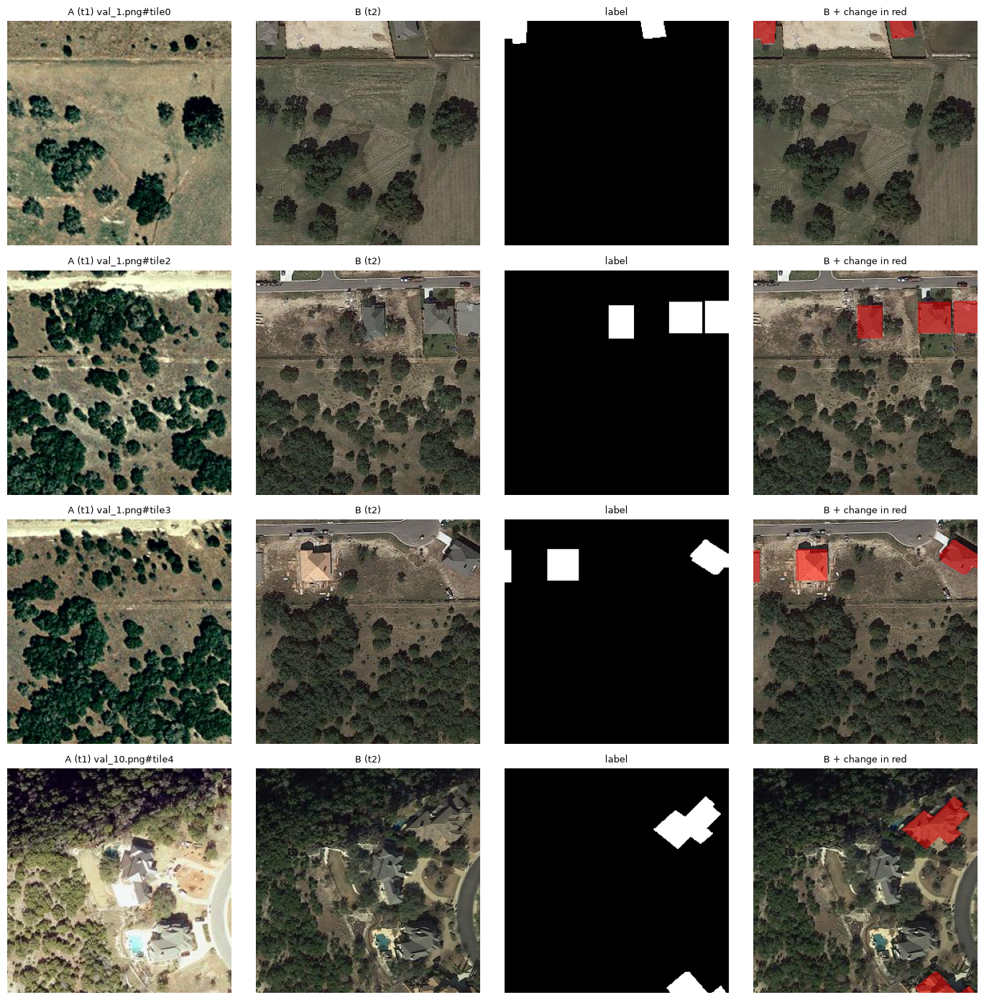

In [8]:
ds_vis = LEVIRCD_Dataset(cropsize=CS, type="val", get_name=True)
idxs = [i for i in range(len(ds_vis)) if ds_vis[i][2].any()][:4]   # tiles that contain change
fig, axes = plt.subplots(len(idxs), 4, figsize=(14, 3.5 * len(idxs)))
for row, i in zip(np.atleast_2d(axes), idxs):
    a, b, l, name = ds_vis[i]
    overlay = b.permute(1, 2, 0).numpy().copy()
    overlay[l.numpy() == 1] = 0.5 * overlay[l.numpy() == 1] + 0.5 * np.array([1, 0, 0])
    for ax, img, title in zip(row, [a.permute(1, 2, 0), b.permute(1, 2, 0), l, overlay],
                              [f"A (t1) {name}", "B (t2)", "label", "B + change in red"]):
        ax.imshow(img, cmap="gray" if img is l else None); ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [9]:
for ds in [ds_val, ds_test]:
    ch = sum(ds[i][2].sum().item() for i in range(len(ds)))
    tot = len(ds) * CS * CS
    print(f"{ds.type}: {100 * ch / tot:.2f}% changed pixels")

val: 4.20% changed pixels
test: 5.09% changed pixels


Verification dataset

In [27]:
# augment=False : HiUCD_Dataset ne fait qu'un crop aléatoire (pas de flips / rotations) -> même chose ici
ds_train = LEVIRCD_Dataset(cropsize=256, type="train", augment=False)
ds_train.names.remove("train_76.png")   # label illisible sur le disque (I/O error) -> 444 paires au lieu de 445
print("nb d'images train :", len(ds_train))
image1, image2, changemap = ds_train[9]

print("image1:", image1.shape, image1.dtype, image1.min().item(), image1.max().item())
print("image2:", image2.shape, image2.dtype, image2.min().item(), image2.max().item())
print("changemap:", changemap.shape, changemap.dtype, torch.unique(changemap))
print("nb d'images train :", len(ds_train))

nb d'images train : 444
image1: torch.Size([3, 256, 256]) torch.float32 0.0 1.0
image2: torch.Size([3, 256, 256]) torch.float32 0.0 0.929411768913269
changemap: torch.Size([256, 256]) torch.int64 tensor([0, 1])
nb d'images train : 444


Apercçu de 1 batch

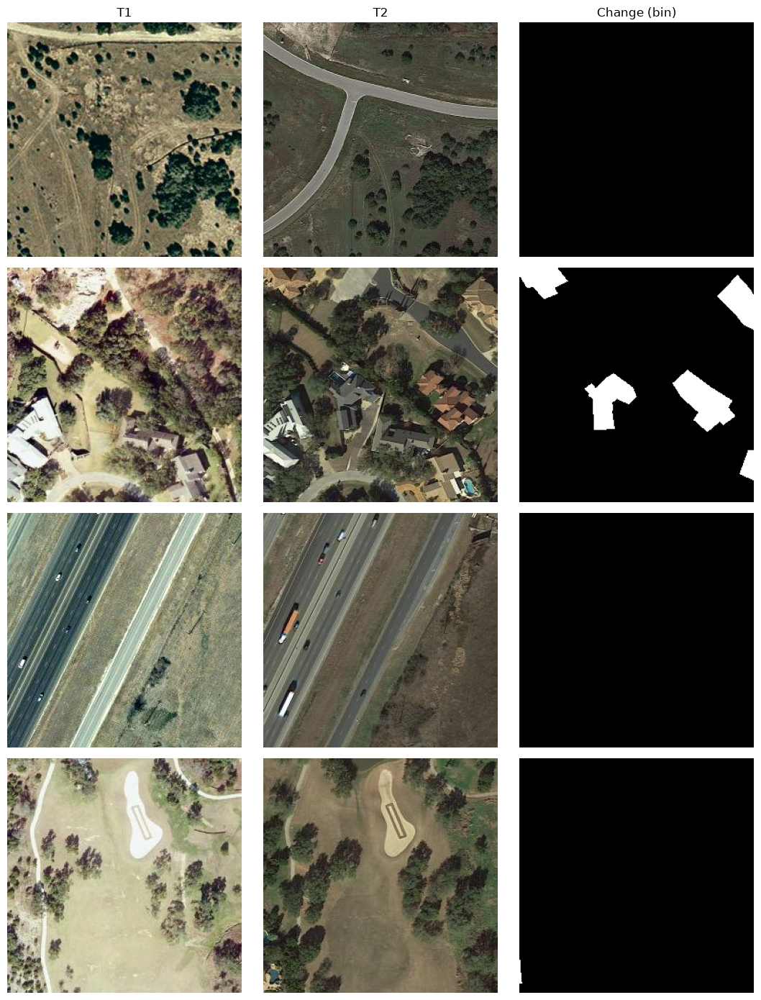

In [28]:
loader = DataLoader(ds_train, batch_size=4, shuffle=True)
image1, image2, changemap = next(iter(loader))

fig, axs = plt.subplots(4, 3, figsize=(11, 14))
titles = ["T1", "T2", "Change (bin)"]
for i in range(4):
    axs[i, 0].imshow(image1[i].permute(1, 2, 0))
    axs[i, 1].imshow(image2[i].permute(1, 2, 0))
    axs[i, 2].imshow(changemap[i], cmap="gray", vmin=0, vmax=1)
    for j in range(3):
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j])
plt.tight_layout()
plt.show()

Check forward

In [14]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6)
model = ChangeDetectionModel(encoder, transformer)

im1, im2, changemap = ds_train[0]
im1_batch, im2_batch = im1.unsqueeze(0), im2.unsqueeze(0)

x_hat, y = model(im1_batch, im2_batch)
print("x_hat:", x_hat.shape, x_hat.requires_grad)
print("y:", y.shape, y.requires_grad)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/home/gaetane/pdseceo/src/encoder.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_encoder_layers)
/home/gaetane/pdseceo/src/encoder.py:59: UserWarning: enable_nested_tensor is True

x_hat: torch.Size([1, 384, 16, 16]) True
y: torch.Size([1, 384, 16, 16]) False


Overfit sur un batch

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


[identity] baseline = 3.9381 | std par token de la cible = 2.359
step    0 | loss 2.835721 | loss/baseline 0.7201 | grad norm 6.2609
step   50 | loss 0.031458 | loss/baseline 0.0080 | grad norm 0.0679
step  100 | loss 0.013866 | loss/baseline 0.0035 | grad norm 0.0105
step  150 | loss 0.007966 | loss/baseline 0.0020 | grad norm 0.0055
step  200 | loss 0.005123 | loss/baseline 0.0013 | grad norm 0.0036
step  250 | loss 0.003585 | loss/baseline 0.0009 | grad norm 0.0026
step  300 | loss 0.002664 | loss/baseline 0.0007 | grad norm 0.0019
step  350 | loss 0.002067 | loss/baseline 0.0005 | grad norm 0.0015
step  400 | loss 0.001658 | loss/baseline 0.0004 | grad norm 0.0012
step  450 | loss 0.001410 | loss/baseline 0.0004 | grad norm 0.0391
step  500 | loss 0.001316 | loss/baseline 0.0003 | grad norm 0.0753
step  550 | loss 0.001103 | loss/baseline 0.0003 | grad norm 0.0606
step  600 | loss 0.002132 | loss/baseline 0.0005 | grad norm 0.2084
step  650 | loss 0.000773 | loss/baseline 0.0002 | 

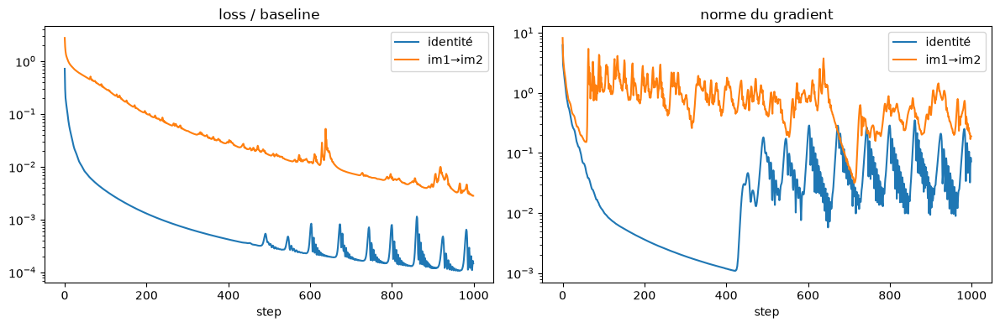

In [15]:
torch.manual_seed(0)
loader = DataLoader(ds_train, batch_size=4, shuffle=True)
im1_fixed, im2_fixed, *_ = next(iter(loader))
im1_fixed, im2_fixed = im1_fixed.to(device), im2_fixed.to(device)

encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224).to(device)


def overfit(target_mode="identity", steps=1000, lr=3e-4):
    torch.manual_seed(0)
    transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.0).to(device)
    model = ChangeDetectionModel(encoder, transformer)

    params = list(model.transformer.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)
    loss_fn = torch.nn.MSELoss()

    with torch.no_grad():
        x_in = encoder(im1_fixed)
        y = x_in.clone() if target_mode == "identity" else encoder(im2_fixed)
        baseline = ((y - y.mean(dim=(0, 2, 3), keepdim=True)) ** 2).mean().item()
        y_std = y.permute(0, 2, 3, 1).reshape(-1, y.shape[1]).std(dim=1).mean().item()
    print(f"[{target_mode}] baseline = {baseline:.4f} | std par token de la cible = {y_std:.3f}")

    losses, gnorms = [], []
    for step in range(steps):
        optimizer.zero_grad()
        x_hat = model.transformer(x_in)
        loss = loss_fn(x_hat, y)
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(params, float("inf")).item()
        optimizer.step()
        losses.append(loss.item())
        gnorms.append(gn)
        if step % 50 == 0 or step == steps - 1:
            print(f"step {step:4d} | loss {loss.item():.6f} | loss/baseline {loss.item()/baseline:.4f} | grad norm {gn:.4f}")

    with torch.no_grad():
        x_hat = model.transformer(x_in)
        x_std = x_hat.permute(0, 2, 3, 1).reshape(-1, x_hat.shape[1]).std(dim=1).mean().item()
    print(f"std par token de x_hat à la fin = {x_std:.3f} (cible : {y_std:.3f})\n")
    return losses, gnorms, baseline


l_id, g_id, b_id = overfit("identity")
l_im2, g_im2, b_im2 = overfit("im2")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for l, g, b, name in [(l_id, g_id, b_id, "identité"), (l_im2, g_im2, b_im2, "im1→im2")]:
    ax[0].plot([v / b for v in l], label=name)
    ax[1].plot(g, label=name)
ax[0].set_yscale("log"); ax[0].set_title("loss / baseline"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].set_yscale("log"); ax[1].set_title("norme du gradient"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

In [16]:
torch.manual_seed(0)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.0).to(device)
model = ChangeDetectionModel(encoder, transformer)

x_hat, y = model(im1_fixed, im2_fixed)
loss = torch.nn.functional.mse_loss(x_hat, y)
loss.backward()

for name, p in transformer.named_parameters():
    g = p.grad.norm().item() if p.grad is not None else None
    print(f"{name}: grad_norm={g}")

transformer.zero_grad()

pos_embed: grad_norm=0.015596368350088596
transformer_encoder.layers.0.self_attn.in_proj_weight: grad_norm=1.6907846927642822
transformer_encoder.layers.0.self_attn.in_proj_bias: grad_norm=0.13336576521396637
transformer_encoder.layers.0.self_attn.out_proj.weight: grad_norm=1.918036699295044
transformer_encoder.layers.0.self_attn.out_proj.bias: grad_norm=0.20767568051815033
transformer_encoder.layers.0.linear1.weight: grad_norm=0.9365087151527405
transformer_encoder.layers.0.linear1.bias: grad_norm=0.0693599283695221
transformer_encoder.layers.0.linear2.weight: grad_norm=2.50555157661438
transformer_encoder.layers.0.linear2.bias: grad_norm=0.20500250160694122
transformer_encoder.layers.0.norm1.weight: grad_norm=0.08803830295801163
transformer_encoder.layers.0.norm1.bias: grad_norm=0.09640070050954819
transformer_encoder.layers.0.norm2.weight: grad_norm=0.03967530280351639
transformer_encoder.layers.0.norm2.bias: grad_norm=0.04178312048316002
transformer_encoder.layers.1.self_attn.in_pr

Gradient circule dans tout les blocs ? 

In [17]:
torch.manual_seed(0)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.0).to(device)
model = ChangeDetectionModel(encoder, transformer)

x_hat, y = model(im1_fixed, im2_fixed)
loss = torch.nn.functional.mse_loss(x_hat, y)
loss.backward()

for name, p in transformer.named_parameters():
    g = p.grad.norm().item() if p.grad is not None else None
    print(f"{name}: grad_norm={g}")

transformer.zero_grad()

pos_embed: grad_norm=0.015596368350088596
transformer_encoder.layers.0.self_attn.in_proj_weight: grad_norm=1.6907846927642822
transformer_encoder.layers.0.self_attn.in_proj_bias: grad_norm=0.13336576521396637
transformer_encoder.layers.0.self_attn.out_proj.weight: grad_norm=1.918036699295044
transformer_encoder.layers.0.self_attn.out_proj.bias: grad_norm=0.20767568051815033
transformer_encoder.layers.0.linear1.weight: grad_norm=0.9365087151527405
transformer_encoder.layers.0.linear1.bias: grad_norm=0.0693599283695221
transformer_encoder.layers.0.linear2.weight: grad_norm=2.50555157661438
transformer_encoder.layers.0.linear2.bias: grad_norm=0.20500250160694122
transformer_encoder.layers.0.norm1.weight: grad_norm=0.08803830295801163
transformer_encoder.layers.0.norm1.bias: grad_norm=0.09640070050954819
transformer_encoder.layers.0.norm2.weight: grad_norm=0.03967530280351639
transformer_encoder.layers.0.norm2.bias: grad_norm=0.04178312048316002
transformer_encoder.layers.1.self_attn.in_pr

Evaluate + valoader

In [18]:
@torch.no_grad()
def evaluate(loader, encoder, transformer):
    encoder.to(device); transformer.to(device); transformer.eval()
    raw_s, mod_s, labels = [], [], []
    for im1, im2, cm, *_ in loader:
        im1, im2 = im1.to(device), im2.to(device)
        x, y = encoder(im1), encoder(im2)
        x_hat = transformer(x)
        for pred, store in [(x, raw_s), (x_hat, mod_s)]:
            err = ((pred - y) ** 2).mean(dim=1, keepdim=True)              # (B,1,16,16)
            err = F.interpolate(err, size=cm.shape[-2:], mode="bilinear", align_corners=False)
            store.append(err.flatten().cpu())
        labels.append(cm.flatten().to(torch.uint8))
    l = torch.cat(labels).numpy()
    out = {}
    for name, s in [("diff brute", raw_s), ("modèle", mod_s)]:
        s = torch.cat(s).numpy()
        out[name] = dict(AUROC=roc_auc_score(l, s), AP=average_precision_score(l, s))
    out["part de pixels changés"] = float(l.mean())
    return out

val_ds = LEVIRCD_Dataset(cropsize=256, type="val")   # val : grille déterministe de 16 tuiles 256x256 par image
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=4)
print("tuiles val :", len(val_ds))

tuiles val : 1024


train

In [30]:
train_loader = DataLoader(ds_train, batch_size=16, shuffle=True, num_workers=4, drop_last=True)
torch.manual_seed(0)
enc_levir = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224).to(device)
tr_levir = FeatureTransformer(embed_dim=enc_levir.out_channels, n_heads=6, dropout=0.1).to(device)

epochs = 20
opt = torch.optim.AdamW(tr_levir.parameters(), lr=3e-4, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4,
                                            total_steps=epochs * len(train_loader), pct_start=0.1)

print("batches par epoch :", len(train_loader), "| total de pas d'optimisation :", epochs * len(train_loader))
for ep in range(epochs):
    tr_levir.train()
    tot = 0.0
    for im1, im2, *_ in train_loader:
        im1, im2 = im1.to(device), im2.to(device)
        with torch.no_grad():
            x, y = enc_levir(im1), enc_levir(im2)
        loss = F.mse_loss(tr_levir(x), y)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        tot += loss.item()
    print(f"epoch {ep}: train loss {tot/len(train_loader):.4f}")

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


batches par epoch : 27 | total de pas d'optimisation : 540


/home/gaetane/pdseceo/src/encoder.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_encoder_layers)
/home/gaetane/pdseceo/src/encoder.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=n_decoder_layers)


epoch 0: train loss 6.4982
epoch 1: train loss 4.9224
epoch 2: train loss 4.2639
epoch 3: train loss 3.8814
epoch 4: train loss 3.6588
epoch 5: train loss 3.5574
epoch 6: train loss 3.5817
epoch 7: train loss 3.4285
epoch 8: train loss 3.3435
epoch 9: train loss 3.3323
epoch 10: train loss 3.2748
epoch 11: train loss 3.2251
epoch 12: train loss 3.2440
epoch 13: train loss 3.1627
epoch 14: train loss 3.1367
epoch 15: train loss 3.1148
epoch 16: train loss 3.1482
epoch 17: train loss 3.1912
epoch 18: train loss 3.1248
epoch 19: train loss 3.1064


histogram avec transformer

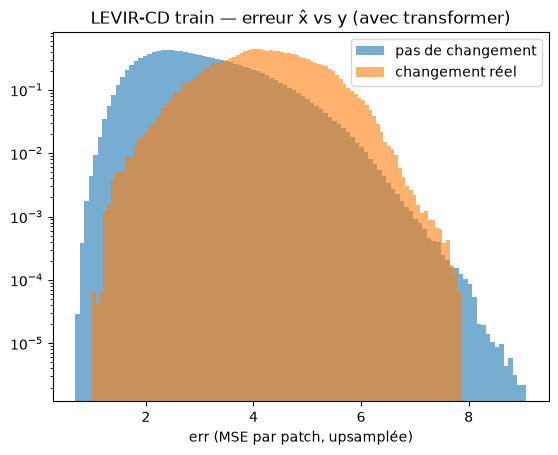

min: 0.68750757 max brut: 9.0682
percentile 95: 4.991925
percentile 99: 5.7909384
percentile 99.9: 6.645385


In [31]:
all_errs = []
all_changes = []

enc_levir.eval().to(device)
tr_levir.eval().to(device)

with torch.no_grad():
    for im1, im2, changemap in train_loader:
        im1, im2 = im1.to(device), im2.to(device)

        x = enc_levir(im1)
        y = enc_levir(im2)
        x_hat = tr_levir(x)

        err = ((x_hat - y) ** 2).mean(dim=1, keepdim=True)  # (B,1,16,16)
        err = F.interpolate(err, size=im1.shape[-2:], mode="bilinear", align_corners=False)
        err = err.squeeze(1).cpu()  # (B, 256, 256)

        all_errs.append(err.flatten())
        all_changes.append(changemap.flatten().to(torch.uint8))

all_errs = torch.cat(all_errs).numpy()
all_changes = torch.cat(all_changes).numpy()

plt.hist(all_errs[all_changes == 0], bins=100, alpha=0.6, label="pas de changement", density=True)
plt.hist(all_errs[all_changes == 1], bins=100, alpha=0.6, label="changement réel", density=True)
plt.yscale("log")
plt.legend()
plt.xlabel("err (MSE par patch, upsamplée)")
plt.title("LEVIR-CD train — erreur x̂ vs y (avec transformer)")
plt.show()

print("min:", all_errs.min(), "max brut:", all_errs.max())
print("percentile 95:", np.percentile(all_errs, 95))
print("percentile 99:", np.percentile(all_errs, 99))
print("percentile 99.9:", np.percentile(all_errs, 99.9))

Histogramme sans transformer

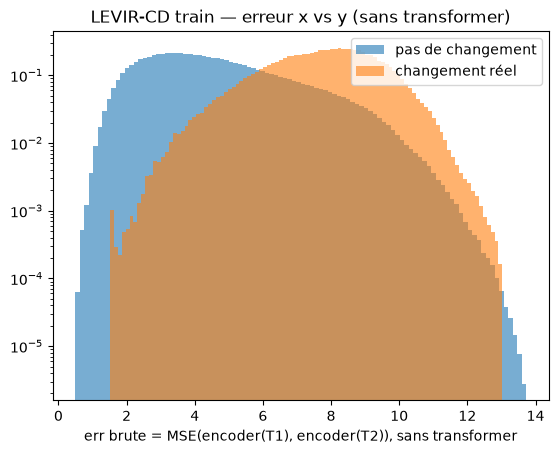

In [32]:
all_errs_raw = []
all_changes_raw = []

enc_levir.eval()

with torch.no_grad():
    for im1, im2, changemap in train_loader:
        im1, im2 = im1.to(device), im2.to(device)

        x = enc_levir(im1)
        y = enc_levir(im2)

        err = ((x - y) ** 2).mean(dim=1, keepdim=True)  # (B,1,16,16)
        err = F.interpolate(err, size=im1.shape[-2:], mode="bilinear", align_corners=False)
        err = err.squeeze(1).cpu()

        all_errs_raw.append(err.flatten())
        all_changes_raw.append(changemap.flatten().to(torch.uint8))

all_errs_raw = torch.cat(all_errs_raw).numpy()
all_changes_raw = torch.cat(all_changes_raw).numpy()

plt.hist(all_errs_raw[all_changes_raw == 0], bins=100, alpha=0.6, label="pas de changement", density=True)
plt.hist(all_errs_raw[all_changes_raw == 1], bins=100, alpha=0.6, label="changement réel", density=True)
plt.yscale("log")
plt.legend()
plt.xlabel("err brute = MSE(encoder(T1), encoder(T2)), sans transformer")
plt.title("LEVIR-CD train — erreur x vs y (sans transformer)")
plt.show()

seuil optimal +courbe avec et sans transformer

[0 1]
[0 1]
avec transformer (x̂ vs y) : seuil optimal = 4.340, F1 = 0.248
sans transformer (x vs y) : seuil optimal = 7.797, F1 = 0.297


/home/gaetane/.conda/envs/pds-eceo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


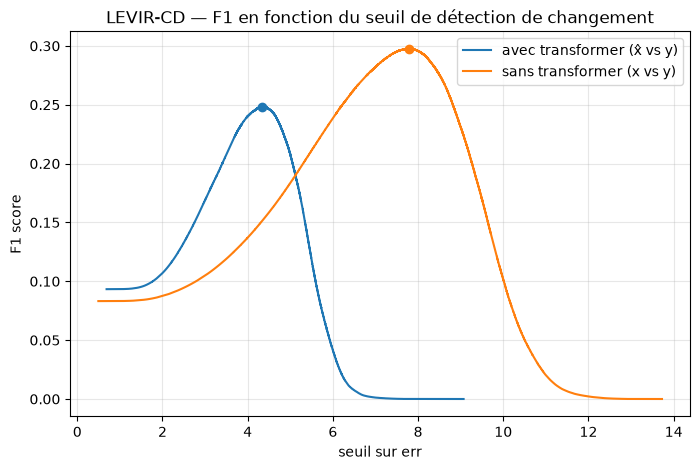

In [36]:
print(np.unique(all_changes))
print(np.unique(all_changes_raw))

def best_f1_threshold(scores, labels):
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    f1 = f1[:-1]
    best_idx = f1.argmax()
    return thresholds[best_idx], f1[best_idx], thresholds, f1

thr_with, f1_with, thr_curve_with, f1_curve_with = best_f1_threshold(all_errs, all_changes)
thr_raw,  f1_raw,  thr_curve_raw,  f1_curve_raw  = best_f1_threshold(all_errs_raw, all_changes_raw)

print(f"avec transformer (x̂ vs y) : seuil optimal = {thr_with:.3f}, F1 = {f1_with:.3f}")
print(f"sans transformer (x vs y) : seuil optimal = {thr_raw:.3f}, F1 = {f1_raw:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(thr_curve_with, f1_curve_with, label="avec transformer (x̂ vs y)")
plt.plot(thr_curve_raw, f1_curve_raw, label="sans transformer (x vs y)")
plt.scatter([thr_with], [f1_with], color="C0", zorder=5)
plt.scatter([thr_raw], [f1_raw], color="C1", zorder=5)
plt.xlabel("seuil sur err")
plt.ylabel("F1 score")
plt.title("LEVIR-CD — F1 en fonction du seuil de détection de changement")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

F1 sur val

In [37]:
torch.manual_seed(42)
all_errs_val = []
all_changes_val = []
all_errs_raw_val = []
all_changes_raw_val = []

enc_levir.eval()
tr_levir.eval()

with torch.no_grad():
    for im1, im2, changemap in val_loader:
        im1, im2 = im1.to(device), im2.to(device)

        x = enc_levir(im1)
        y = enc_levir(im2)
        x_hat = tr_levir(x)

        err = ((x_hat - y) ** 2).mean(dim=1, keepdim=True)
        err = F.interpolate(err, size=im1.shape[-2:], mode="bilinear", align_corners=False)
        err = err.squeeze(1).cpu()

        err_raw = ((x - y) ** 2).mean(dim=1, keepdim=True)
        err_raw = F.interpolate(err_raw, size=im1.shape[-2:], mode="bilinear", align_corners=False)
        err_raw = err_raw.squeeze(1).cpu()

        all_errs_val.append(err.flatten())
        all_changes_val.append(changemap.flatten().to(torch.uint8))
        all_errs_raw_val.append(err_raw.flatten())
        all_changes_raw_val.append(changemap.flatten().to(torch.uint8))

all_errs_val = torch.cat(all_errs_val).numpy()
all_changes_val = torch.cat(all_changes_val).numpy()
all_errs_raw_val = torch.cat(all_errs_raw_val).numpy()
all_changes_raw_val = torch.cat(all_changes_raw_val).numpy()
print("nb de pixels au-dessus du seuil dans all_errs_val :", (all_errs_val > thr_with).sum())
f1_with_on_val = f1_score(all_changes_val, all_errs_val > thr_with)
f1_raw_on_val = f1_score(all_changes_raw_val, all_errs_raw_val > thr_raw)

print(f"avec transformer : seuil train = {thr_with:.3f} → F1 sur val = {f1_with_on_val:.3f}")
print(f"sans transformer : seuil train = {thr_raw:.3f} → F1 sur val = {f1_raw_on_val:.3f}")

nb de pixels au-dessus du seuil dans all_errs_val : 7302359
avec transformer : seuil train = 4.340 → F1 sur val = 0.255
sans transformer : seuil train = 7.797 → F1 sur val = 0.302


visualize predction 

err.max() sur ces exemples : 8.379312515258789 | seuil : 4.33996
pixels prédits positifs par image : [655, 32178, 12220, 5400, 3672, 139, 433, 928, 1510, 2740, 0, 5355, 6237, 14761, 4970, 4475, 2414, 0, 46487, 1950]


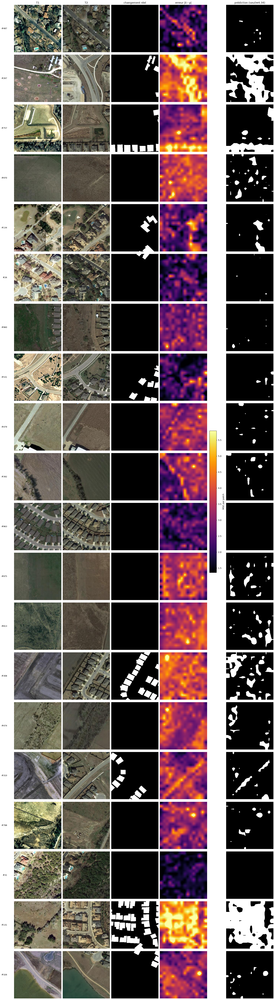

In [40]:
@torch.no_grad()
def visualize_predictions(encoder, transformer, dataset, device, n=20, seed=0, save_path=None,
                           vmin=0, vmax=None, threshold=None):
    """Affiche n paires : T1, T2, changement réel, erreur |x_hat - y|, prédiction binaire (seuil)."""
    transformer.eval()
    torch.manual_seed(seed)
    indices = random.Random(seed).sample(range(len(dataset)), n)

    samples = [dataset[idx] for idx in indices]
    im1_batch = torch.stack([s[0] for s in samples]).to(device)
    im2_batch = torch.stack([s[1] for s in samples]).to(device)
    changemaps = [s[2] for s in samples]

    x = encoder(im1_batch)
    y = encoder(im2_batch)
    x_hat = transformer(x)

    err = ((x_hat - y) ** 2).mean(dim=1, keepdim=True)
    err = F.interpolate(err, size=im1_batch.shape[-2:], mode="bilinear", align_corners=False)
    err = err.squeeze(1).cpu()                     # (n, H, W)

    if threshold is not None:
        binary_pred = (err > threshold).float()
        print("err.max() sur ces exemples :", err.max().item(), "| seuil :", threshold)
        print("pixels prédits positifs par image :", (err > threshold).sum(dim=(1, 2)).tolist())

    im1_cpu, im2_cpu = im1_batch.cpu(), im2_batch.cpu()

    ncols = 5 if threshold is not None else 4
    fig, axs = plt.subplots(n, ncols, figsize=(3.5 * ncols, 3.2 * n), constrained_layout=True)
    titles = ["T1", "T2", "changement réel", "erreur |x̂ - y|"]
    if threshold is not None:
        titles.append(f"prédiction (seuil={threshold:.2f})")
    err_im = None

    for row, idx in enumerate(indices):
        axs[row, 0].imshow(im1_cpu[row].permute(1, 2, 0))
        axs[row, 1].imshow(im2_cpu[row].permute(1, 2, 0))
        axs[row, 2].imshow(changemaps[row].squeeze(), cmap="gray", vmin=0, vmax=1)
        err_im = axs[row, 3].imshow(err[row], cmap="inferno", vmin=vmin, vmax=vmax)
        if threshold is not None:
            axs[row, 4].imshow(binary_pred[row], cmap="gray", vmin=0, vmax=1)

        for col in range(ncols):
            axs[row, col].axis("off")
            if row == 0:
                axs[row, col].set_title(titles[col])
        axs[row, 0].text(-0.15, 0.5, f"#{idx}", transform=axs[row, 0].transAxes, ha="right", va="center", fontsize=9)

    fig.colorbar(err_im, ax=axs[:, 3], shrink=0.6, label="MSE par patch")

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print("figure sauvegardée :", save_path)
    plt.show()

visualize_predictions(enc_levir, tr_levir, val_ds, device, n=20, seed=3,
                      vmin=np.percentile(all_errs, 1), vmax=np.percentile(all_errs, 99),
                      threshold=thr_with)

In [41]:
@torch.no_grad()
def find_positive_indices(encoder, transformer, dataset, device, threshold, batch_size=8, seed=42):
    torch.manual_seed(seed)
    encoder.eval(); transformer.eval()
    positive_indices = []
    for start in range(0, len(dataset), batch_size):
        idxs = list(range(start, min(start + batch_size, len(dataset))))
        samples = [dataset[i] for i in idxs]
        im1 = torch.stack([s[0] for s in samples]).to(device)
        im2 = torch.stack([s[1] for s in samples]).to(device)

        x = encoder(im1)
        y = encoder(im2)
        x_hat = transformer(x)
        err = ((x_hat - y) ** 2).mean(dim=1, keepdim=True)
        err = F.interpolate(err, size=im1.shape[-2:], mode="bilinear", align_corners=False).squeeze(1)

        counts = (err > threshold).sum(dim=(1, 2))
        for i, c in zip(idxs, counts):
            if c.item() > 0:
                positive_indices.append((i, c.item()))

    return positive_indices

pos = find_positive_indices(enc_levir, tr_levir, val_ds, device, threshold=thr_with)
print(f"{len(pos)} tuiles sur {len(val_ds)} ont au moins un pixel prédit positif")
print(sorted(pos, key=lambda x: -x[1])[:10])

974 tuiles sur 1024 ont au moins un pixel prédit positif
[(740, 65536), (476, 61618), (636, 61494), (445, 60885), (623, 59628), (862, 59176), (852, 58918), (676, 58862), (329, 58815), (275, 58618)]
